# Configure Merge Module Params

This notebook should be used as a test for ensuring correct merge parameters before merge processing.
Cells marked with <font color='red'>SET PARAMETERS</font> contain crucial variables that need to be set according to your specific experimental setup and data organization.
Please review and modify these variables as needed before proceeding with the analysis.

## <font color='red'>SET PARAMETERS</font>

### Fixed parameters for merge processing

- `CONFIG_FILE_PATH`: Path to a Brieflow config file used during processing. Absolute or relative to where workflows are run from.

In [1]:
CONFIG_FILE_PATH = "config/config.yml"

In [ ]:
import warnings
from pathlib import Path

import yaml
import pandas as pd

from lib.shared.file_utils import get_filename
from lib.shared.configuration_utils import (
    plot_combined_tile_grid,
    plot_merge_example,
    CONFIG_FILE_HEADER,
)
from lib.merge.hash import hash_cell_locations, initial_alignment
from lib.merge.eval_alignment import plot_alignment_quality

In [ ]:
def find_closest_sites(ph_metadata, sbs_metadata, ph_tile_id):
    """
    Find closest SBS sites in sbs_metadata to a specific phenotype tile in ph_metadata.
    
    Args:
        ph_metadata: DataFrame with x_pos, y_pos columns
        sbs_metadata: DataFrame with x_pos, y_pos columns  
        ph_tile_id: ID of phenotype tile to find closest SBS sites for
    
    Returns:
        DataFrame of SBS sites sorted by distance to ph_tile_id
    """
    # Get phenotype tile coordinates
    ph_tile = ph_metadata[ph_metadata.tile == ph_tile_id]
    print(f"Finding closest SBS sites to phenotype tile ID: {ph_tile_id}")
    print(f"Phenotype tile coordinates: {ph_tile[['x_pos', 'y_pos']].iloc[0].to_dict()}")
    
    ph_x, ph_y = ph_tile['x_pos'].iloc[0], ph_tile['y_pos'].iloc[0]
    
    # Calculate distances to all SBS tiles
    distances = np.sqrt((sbs_metadata['x_pos'] - ph_x)**2 + (sbs_metadata['y_pos'] - ph_y)**2)
    
    # Return sorted results
    result = sbs_metadata.copy()
    result['distance'] = distances
    return result.sort_values('distance')

## <font color='red'>SET PARAMETERS</font>

### Determine merge plate-well combos
- `MERGE_COMBO_DF_FP`: Plate used for testing configuration

In [3]:
MERGE_COMBO_DF_FP = "config/merge_combo.tsv"

In [4]:
# load config file and determine root path
with open(CONFIG_FILE_PATH, "r") as config_file:
    config = yaml.safe_load(config_file)

SBS_COMBO_FP = Path(config["preprocess"]["sbs_combo_fp"])
sbs_wildcard_combos = pd.read_csv(SBS_COMBO_FP, sep="\t")
PHENOTYPE_COMBO_FP = Path(config["preprocess"]["phenotype_combo_fp"])
phenotype_wildcard_combos = pd.read_csv(PHENOTYPE_COMBO_FP, sep="\t")

# Generate plate-well combinations for merge
sbs_combos = set(zip(sbs_wildcard_combos["plate"], sbs_wildcard_combos["well"]))
phenotype_combos = set(
    zip(phenotype_wildcard_combos["plate"], phenotype_wildcard_combos["well"])
)
# Check if SBS and PHENOTYPE have the same plate-well combinations
if sbs_combos == phenotype_combos:
    merge_wildcard_combos = pd.DataFrame(list(sbs_combos), columns=["plate", "well"])
else:
    warnings.warn(
        "SBS and PHENOTYPE do not have matching plate-well combinations. Merging requires identical sets."
    )
    merge_wildcard_combos = pd.DataFrame(columns=["plate", "well"])

merge_wildcard_combos.to_csv(MERGE_COMBO_DF_FP, sep="\t", index=False)
merge_wildcard_combos

,plate,well
0,1,A3
1,1,B2


## <font color='red'>SET PARAMETERS</font>

### Parameters for testing merge module
- `TEST_PLATE`: Plate used for testing configuration 
- `TEST_WELL`: Well identifier used for testing configuration 

### Parameters for metadata extraction
- `SBS_METADATA_CYCLE`: Cycle number for extracting SBS data positions
- `SBS_METADATA_CHANNEL`: Optional channel for SBS metadata. This is necessary in the case that multiple channel-based images were acquired, and therefore, multiple channel-based metadata files exist.
- `PH_METADATA_CHANNEL`: Optional channel for phenotype metadata. This is necessary in the case that multiple channel-based images were acquired, and therefore, multiple channel-based metadata files exist.

In [5]:
TEST_PLATE = 1
TEST_WELL = "A3"

SBS_METADATA_CYCLE = 1
SBS_METADATA_CHANNEL = None
PH_METADATA_CHANNEL = None

/lab/ops_analysis/lourido/nebo-analysis/brieflow/workflow/lib/shared/configuration_utils.py:301: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/lab/solexa_lourido/USERS/AK/miniforge3/envs/brieflow_nebo/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/lab/solexa_lourido/USERS/AK/miniforge3/envs/brieflow_nebo/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


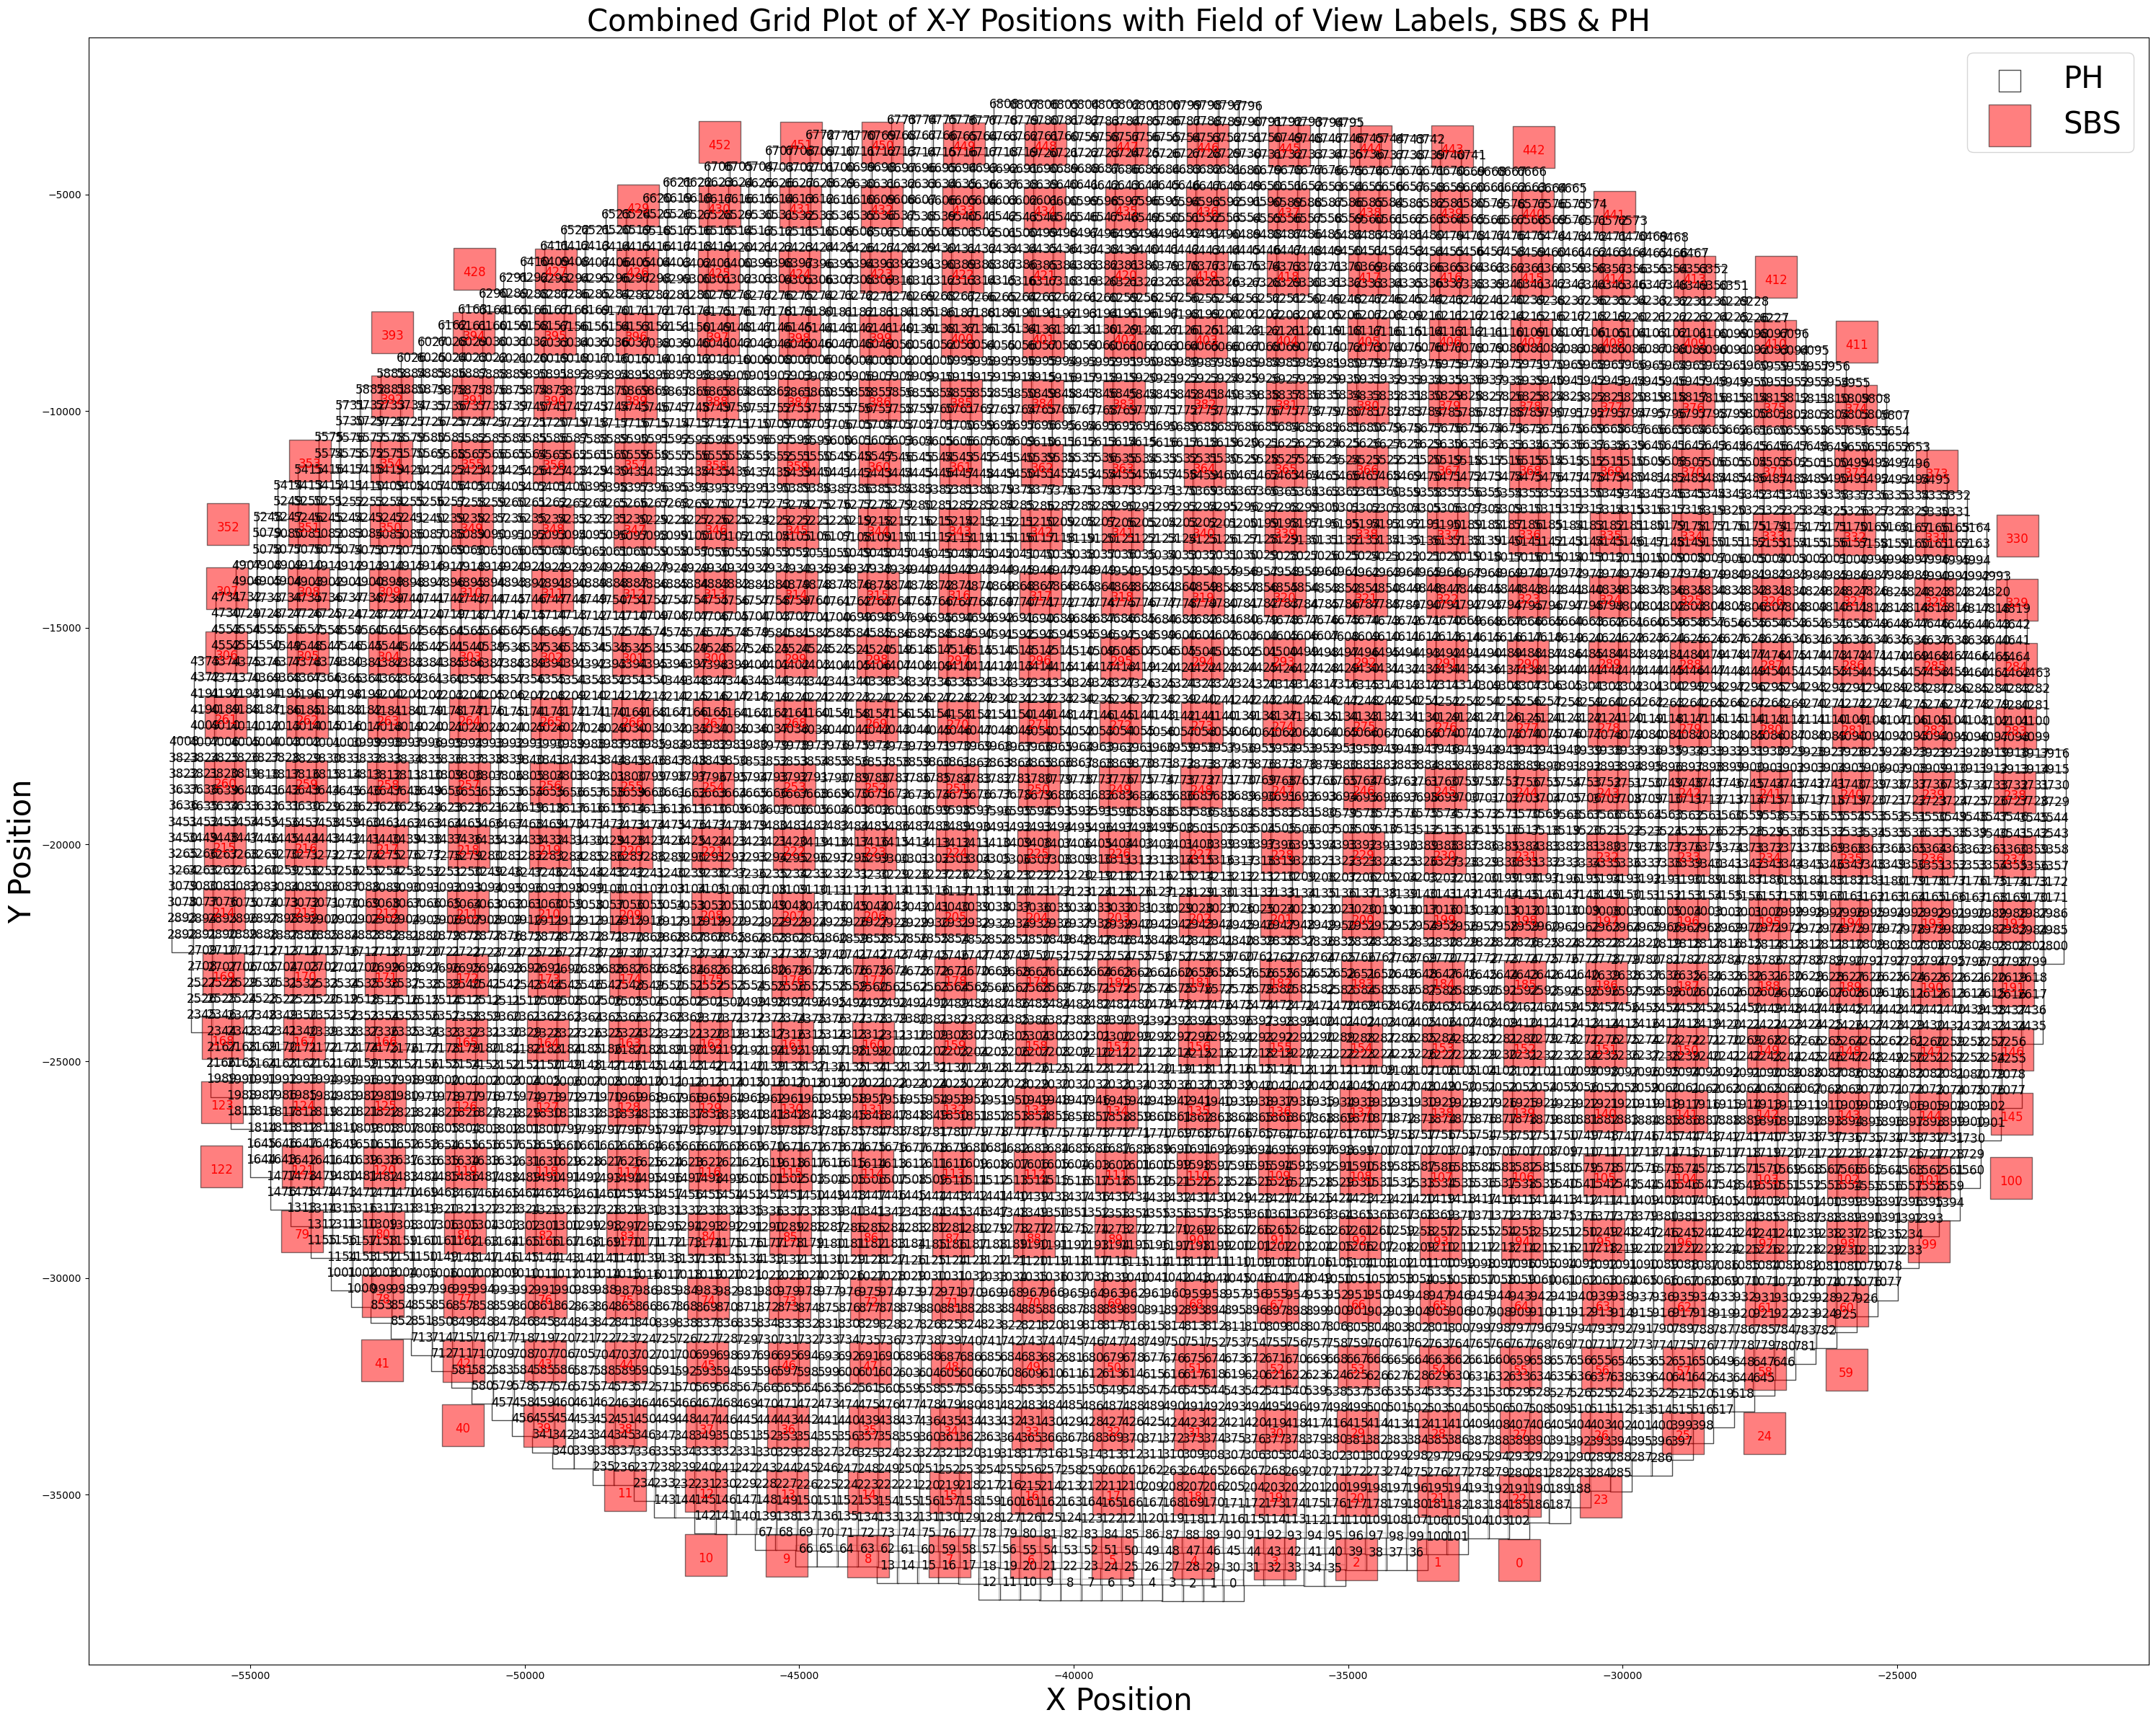

In [6]:
ROOT_FP = Path(config["all"]["root_fp"])

# load phenotype and SBS metadata dfs
ph_filename_params = {"plate": TEST_PLATE, "well": TEST_WELL}
if PH_METADATA_CHANNEL is not None:
    ph_filename_params["channel"] = PH_METADATA_CHANNEL

ph_test_metadata_fp = (
    ROOT_FP
    / "preprocess"
    / "metadata"
    / "phenotype"
    / get_filename(ph_filename_params, "combined_metadata", "parquet")
)
ph_test_metadata = pd.read_parquet(ph_test_metadata_fp)

sbs_filename_params = {"plate": TEST_PLATE, "well": TEST_WELL}
if SBS_METADATA_CHANNEL is not None:
    sbs_filename_params["channel"] = SBS_METADATA_CHANNEL

sbs_test_metadata_fp = (
    ROOT_FP
    / "preprocess"
    / "metadata"
    / "sbs"
    / get_filename(sbs_filename_params, "combined_metadata", "parquet")
)
sbs_test_metadata = pd.read_parquet(sbs_test_metadata_fp)
sbs_test_metadata = sbs_test_metadata[sbs_test_metadata["cycle"] == SBS_METADATA_CYCLE]

# create plot with combined tile view
combined_tile_grid = plot_combined_tile_grid(ph_test_metadata, sbs_test_metadata)
combined_tile_grid.show()

## <font color='red'>SET PARAMETERS</font>

### Parameters for testing merge processing

- `INITIAL_SITES`: Combinations of phenotype and SBS tiles used for configuring merge module parameters. Based on the combined grid above, set 6 aligned intial sites. We will load images for one of those sites, to ensure that we can visualize cell patterns (using the DAPI channel) that correspond between two tiles that will make up our initial sites. We recommend using aligned sites from across the plate.

In [77]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans

# Load the data
phenotype_info = pd.read_parquet("/lab/ops_analysis/lourido/nebo-analysis/analysis/analysis_root/phenotype/parquets/P-1_W-A3__phenotype_info.parquet")

# Count number of cells per tile
tile_counts = phenotype_info['tile'].value_counts().reset_index()
tile_counts.columns = ['tile', 'cell_count']

# Filter out tiles with more than 80 cells
tile_counts = tile_counts[tile_counts['cell_count'] <= 65]

# Estimate grid dimensions (assuming contiguous tile numbers starting from 0)
n_tiles = tile_counts['tile'].max() + 1
grid_size = int(np.ceil(np.sqrt(n_tiles)))

# Estimate (x, y) position of each tile
tile_counts['x'] = tile_counts['tile'] % grid_size
tile_counts['y'] = tile_counts['tile'] // grid_size

# Cluster tile positions into 6 geographic regions
kmeans = KMeans(n_clusters=6, random_state=0)
tile_counts['region'] = kmeans.fit_predict(tile_counts[['x', 'y']])

# Pick the top tile (by cell count) from each region
selected_tiles = tile_counts.sort_values('cell_count', ascending=False).groupby('region').first().reset_index()

print("Selected 6 tiles:")
print(selected_tiles[['tile', 'cell_count', 'region']])


Selected 6 tiles:
   tile  cell_count  region
0  6577          64       0
1  1077          64       1
2  2986          65       2
3  2427          65       3
4  3180          56       4
5  5809          65       5


In [119]:

closest = find_closest_sites(ph_test_metadata, sbs_test_metadata, 3180)
print(closest.head())


Finding closest SBS sites to phenotype tile ID: 3180
Phenotype tile coordinates: {'x_pos': -25107.7, 'y_pos': -21002.6}
       x_pos    y_pos    z_pos  pfs_offset  plate well  tile  cycle  \
235 -25827.2 -20259.5  3121.30        <NA>      1   A3   235      1   
194 -25838.9 -21741.4  3114.20        <NA>      1   A3   194      1   
236 -24345.2 -20271.6  3119.56        <NA>      1   A3   236      1   
193 -24357.1 -21753.5  3114.00        <NA>      1   A3   193      1   
234 -27309.0 -20247.7  3122.34        <NA>      1   A3   234      1   

                                              filename  channels  \
235  /lab/ops_data/nebo/plate_1/input_sbs/c1/10x/P0...         5   
194  /lab/ops_data/nebo/plate_1/input_sbs/c1/10x/P0...         5   
236  /lab/ops_data/nebo/plate_1/input_sbs/c1/10x/P0...         5   
193  /lab/ops_data/nebo/plate_1/input_sbs/c1/10x/P0...         5   
234  /lab/ops_data/nebo/plate_1/input_sbs/c1/10x/P0...         5   

     pixel_size_x  pixel_size_y     distance

In [ ]:
INITIAL_SITES = [
    [2795, 190], 
    [5809, 374], 
    [2996, 194],
    ]

In [127]:
import pandas as pd
import numpy as np

def find_closest_tiles(sbs_metadata, ph_metadata, sbs_tile_id):
    """
    Find closest tiles in ph_metadata to a specific tile in sbs_metadata
    
    Args:
        sbs_metadata: DataFrame with x_pos, y_pos columns
        ph_metadata: DataFrame with x_pos, y_pos columns  
        sbs_tile_id: ID of sbs tile to find neighbors for
    
    Returns:
        DataFrame of ph tiles sorted by distance to sbs_tile_id
    """
    # Get sbs tile coordinates
    sbs_tile = sbs_metadata[sbs_metadata.tile == sbs_tile_id]
    print(f"Finding closest tiles to SBS tile ID: {sbs_tile_id}")
    print(f"SBS tile coordinates: {sbs_tile[['x_pos', 'y_pos']].iloc[0].to_dict()}")
    sbs_x, sbs_y = sbs_tile['x_pos'].iloc[0], sbs_tile['y_pos'].iloc[0]
    
    # Calculate distances to all ph tiles
    distances = np.sqrt((ph_metadata['x_pos'] - sbs_x)**2 + (ph_metadata['y_pos'] - sbs_y)**2)
    
    # Return sorted results
    result = ph_metadata.copy()
    result['distance'] = distances
    return result.sort_values('distance')

# # Usage:
# closest = find_closest_tiles(sbs_test_metadata, ph_test_metadata, 15)
# print(closest.head())

# closest = find_closest_tiles(sbs_test_metadata, ph_test_metadata, 62)
# print(closest.head())

# closest = find_closest_tiles(sbs_test_metadata, ph_test_metadata, 170)
# print(closest.head())

# closest = find_closest_tiles(sbs_test_metadata, ph_test_metadata, 291)
# print(closest.head())

closest = find_closest_tiles(sbs_test_metadata, ph_test_metadata, 194)
print(closest.head())

# closest = find_closest_tiles(sbs_test_metadata, ph_test_metadata, 400)
# print(closest.head())

Finding closest tiles to SBS tile ID: 194
SBS tile coordinates: {'x_pos': -25838.9, 'y_pos': -21741.4}
        x_pos    y_pos    z_pos  pfs_offset  plate well  tile  \
2996 -25854.5 -21737.6  3127.24        <NA>      1   A3  2996   
2995 -25484.2 -21740.4  3126.98        <NA>      1   A3  2995   
2975 -25857.4 -22108.3  3128.38        <NA>      1   A3  2975   
3161 -25851.5 -21367.2  3127.62        <NA>      1   A3  3161   
2997 -26225.1 -21734.5  3127.42        <NA>      1   A3  2997   

                                               filename  channels  \
2996  /lab/ops_data/nebo/plate_1/input_ph/round_1/20...         4   
2995  /lab/ops_data/nebo/plate_1/input_ph/round_1/20...         4   
2975  /lab/ops_data/nebo/plate_1/input_ph/round_1/20...         4   
3161  /lab/ops_data/nebo/plate_1/input_ph/round_1/20...         4   
2997  /lab/ops_data/nebo/plate_1/input_ph/round_1/20...         4   

      pixel_size_x  pixel_size_y    distance  
2996        0.1625        0.1625   16.056151

In [141]:
# Derive sites for phenotype and sbs
phenotype_tiles = [site[0] for site in INITIAL_SITES]
sbs_tiles = [site[1] for site in INITIAL_SITES]

# Derive phenotype alignment hash
phenotype_info_fp = (
    ROOT_FP
    / "phenotype"
    / "parquets"
    / get_filename(
        {"plate": TEST_PLATE, "well": TEST_WELL}, "phenotype_info", "parquet"
    )
)
phenotype_info = pd.read_parquet(phenotype_info_fp)
phenotype_info_hash = hash_cell_locations(phenotype_info)

# Derive SBS alignment hash
sbs_info_fp = (
    ROOT_FP
    / "sbs"
    / "parquets"
    / get_filename({"plate": TEST_PLATE, "well": TEST_WELL}, "sbs_info", "parquet")
)
sbs_info = pd.read_parquet(sbs_info_fp)
sbs_info_hash = hash_cell_locations(sbs_info).rename(columns={"tile": "site"})

# Perform alignment for initial sites
initial_alignment_df = initial_alignment(
    phenotype_info_hash, sbs_info_hash, initial_sites=INITIAL_SITES
)
initial_alignment_df

,rotation,translation,score,determinant,site,tile
0,NaN,NaN,-1.0,NaN,422.0,6312.0


In [143]:
print(sbs_info_hash)

            V_0         V_1         V_2         V_3         V_4         V_5  \
0    187.473823    4.093885  -64.475861  125.620789 -122.997962 -129.714674   
1    111.241201 -277.169751    9.320116   60.334494 -120.561317  216.835257   
2    102.945887 -180.389142  -17.421835   50.582071  -85.524052  129.807071   
3     -2.736249  386.507824   -0.972523 -182.037297    3.708772 -204.470526   
4   -187.473823   -4.093885  132.125957  -76.595663   55.347866   80.689549   
..          ...         ...         ...         ...         ...         ...   
373   -5.530579   24.484298   -1.514876  -10.284298    7.045455  -14.200000   
374  -13.300622  -16.365346   20.346076    2.165346   -7.045455   14.200000   
375   20.615808  -28.292521    1.514876   10.284298  -22.130684   18.008224   
376  -44.839017   -1.290485   31.538395  -15.074861   13.300622   16.365346   
377   44.839017    1.290485  -20.615808   28.292521  -24.223208  -29.583006   

            V_6         V_7         V_8         V_9

## <font color='red'>SET PARAMETERS</font>

### Visualize gating strategy based on initial alignment

- `DET_RANGE`: Enforces valid magnification ratios between phenotype and genotype images. It needs to be adjusted based on:
    - Objective magnifications used (e.g., 20X vs 10X)
    - Camera binning settings (e.g., 2x2 binning vs unbinned)
    - To calculate for your setup:
        1. Determine total magnification difference (objectives × binning)
        2. Use (min/difference², max/difference²) where min/max are typically 0.9-1.15
    - You can narrow or expand the suggested `DET_RANGE` based on how closely or widely you want to ensure matches
- `SCORE` This parameter is the score of the transformation, typically 0.1

In [130]:
DET_RANGE = (0.015, 0.017)
SCORE = 0.1

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Alignment Quality Check\nScore vs Determinant'}, xlabel='Determinant', ylabel='Score'>)

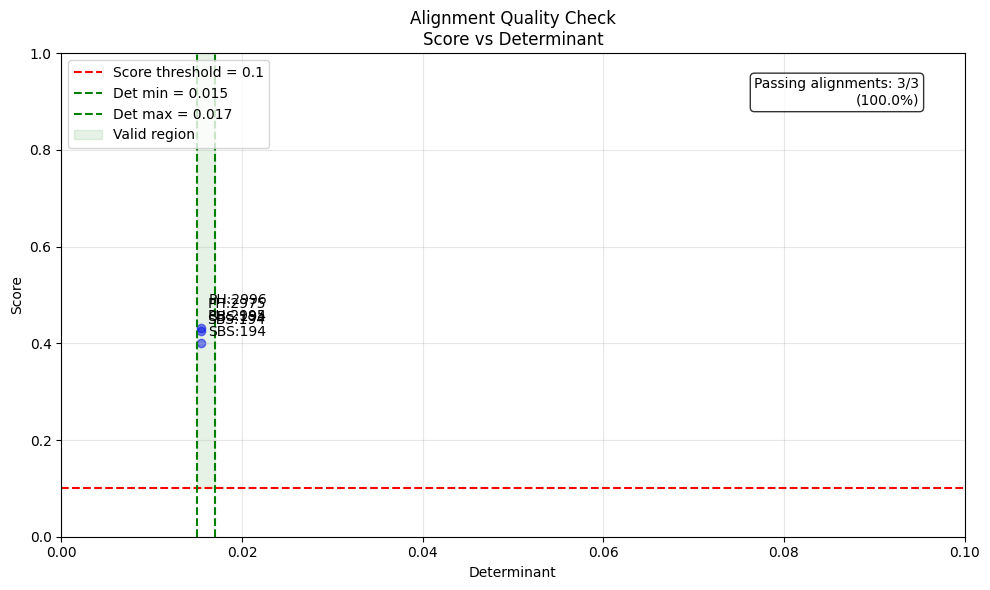

In [131]:
plot_alignment_quality(
    initial_alignment_df, det_range=DET_RANGE, score=SCORE, xlim=(0, 0.1), ylim=(0, 1)
)

## <font color='red'>SET PARAMETERS</font>

### Visualize cell matches based on initial alignment

- `THRESHOLD`: Determines the maximum euclidean distance between a phenotype point and its matched SBS point for them to be considered a valid match

In [136]:
THRESHOLD = 10

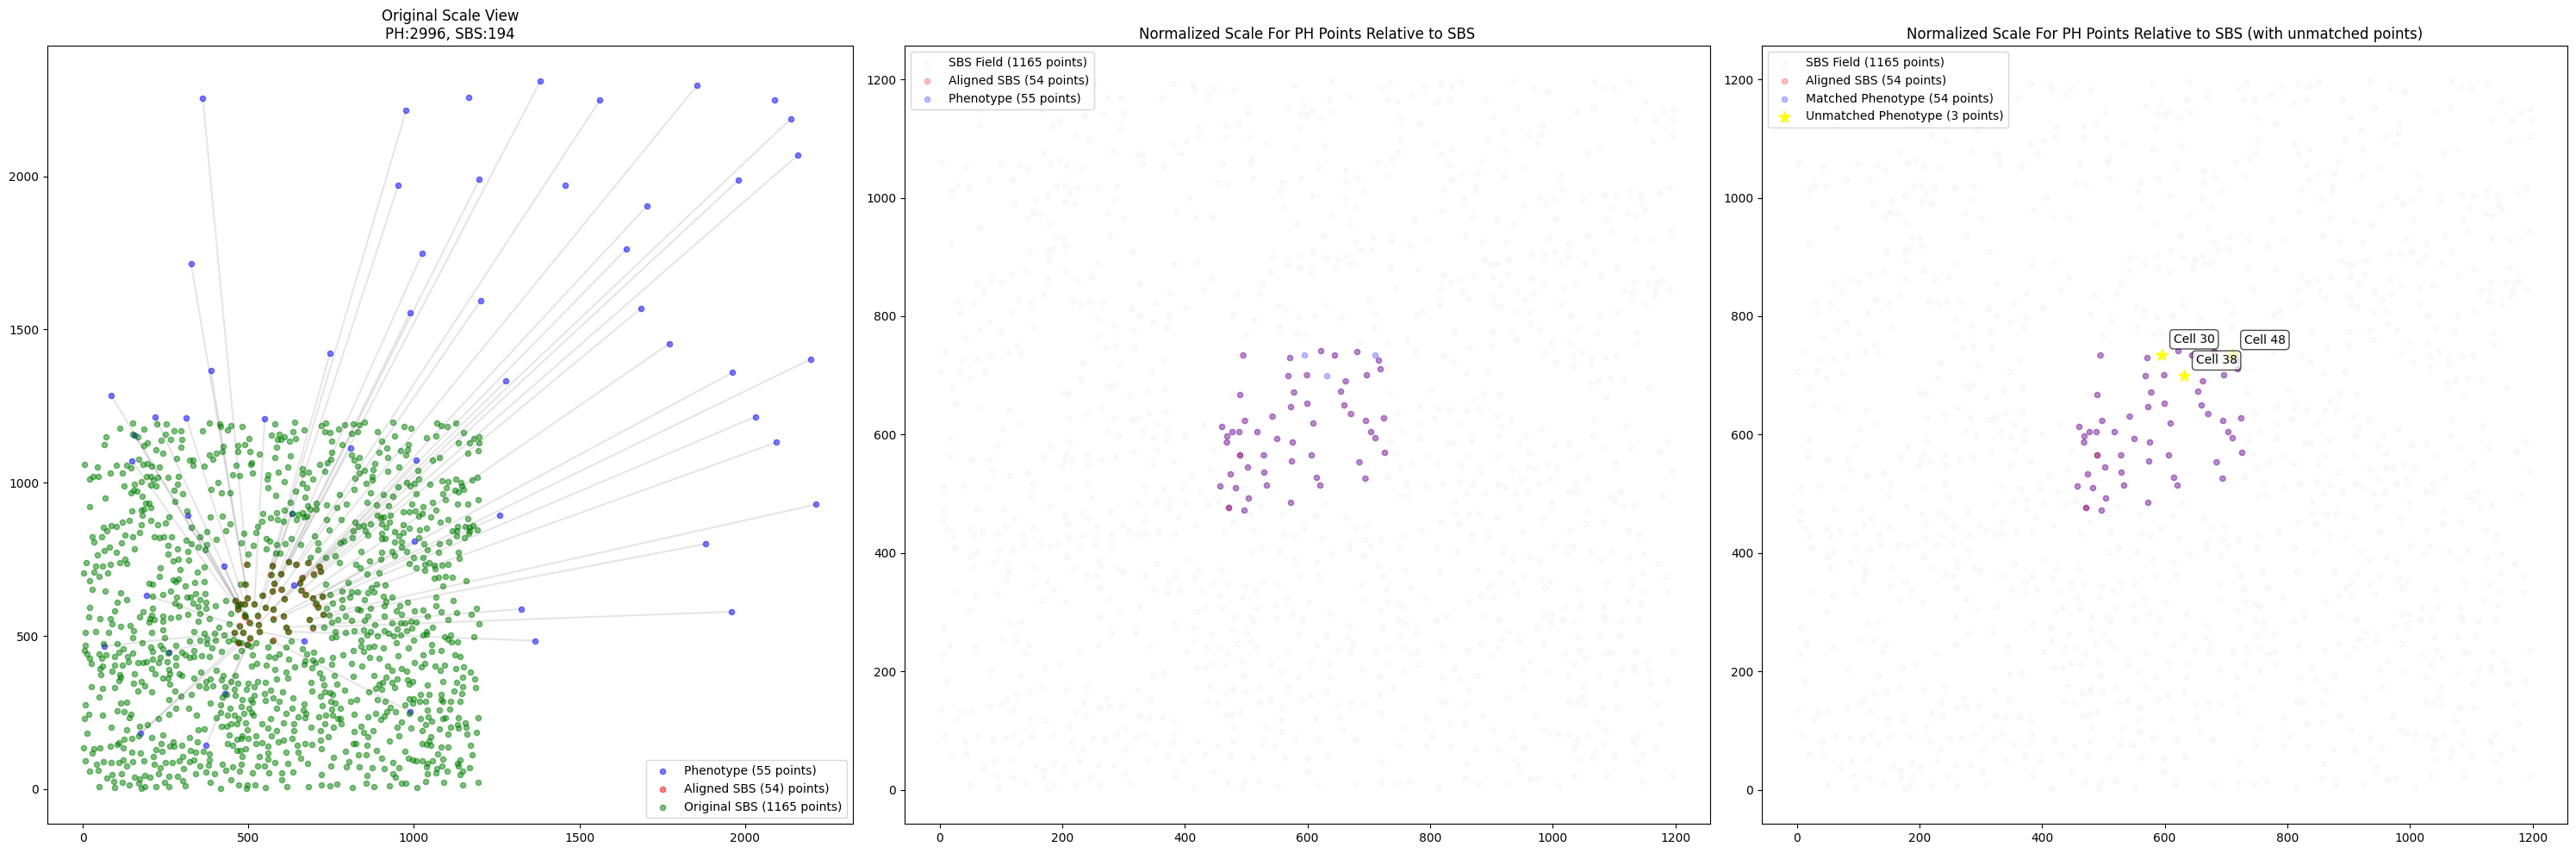

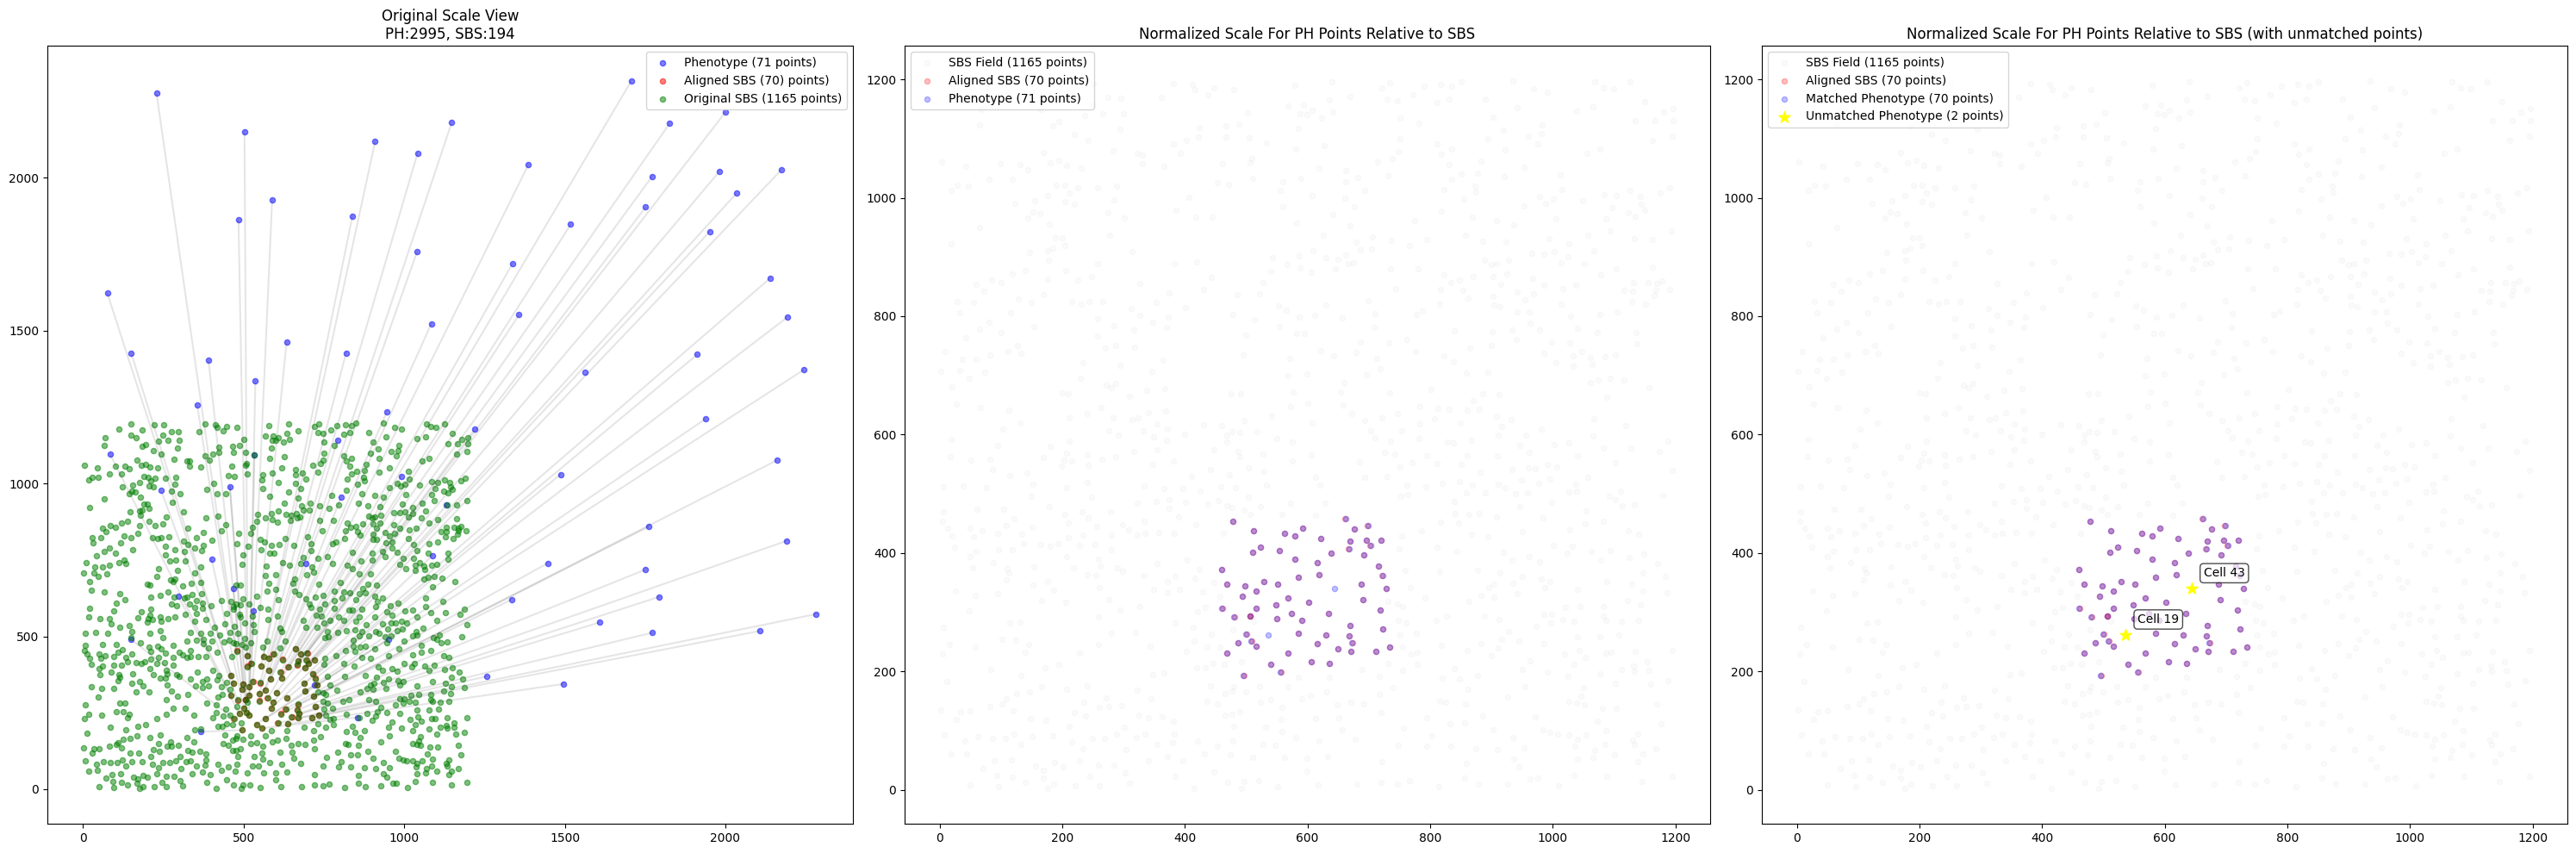

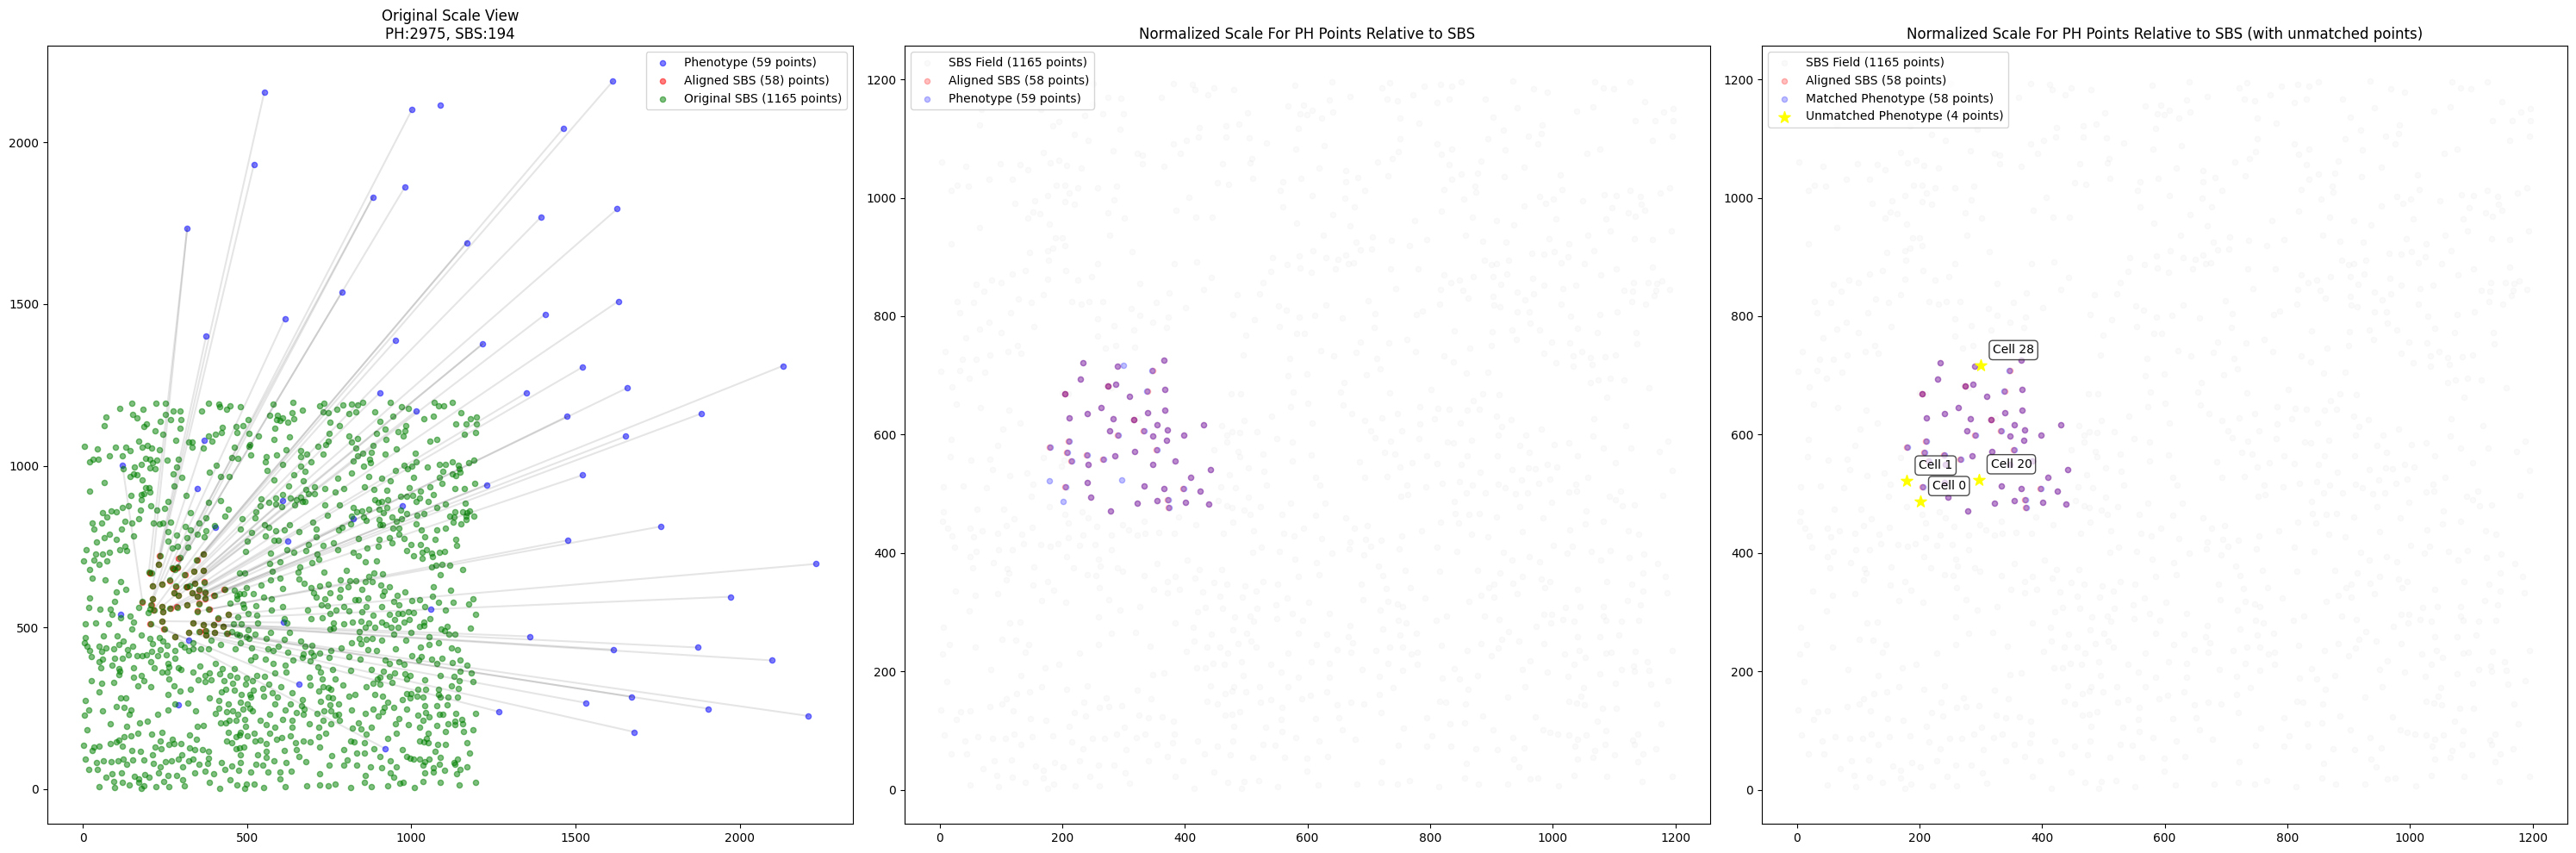

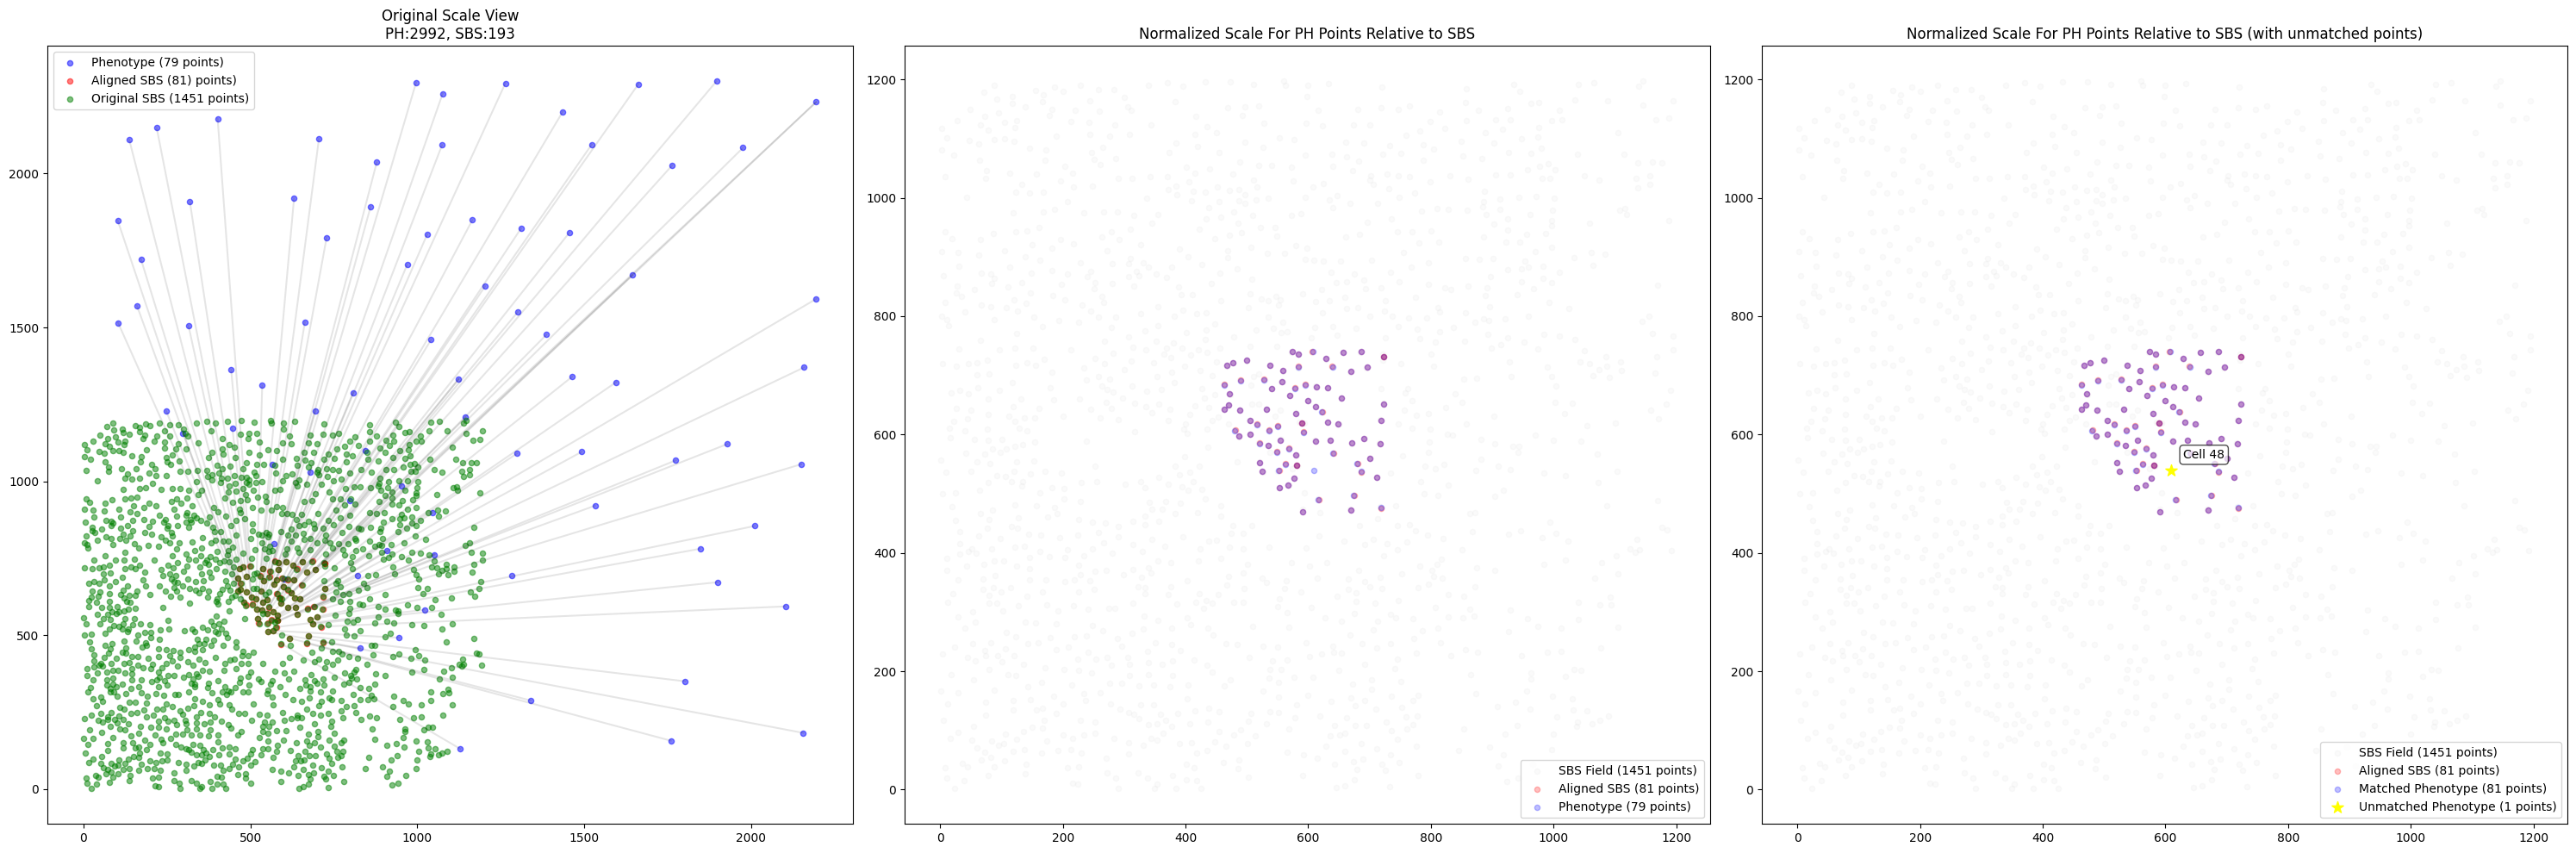

In [137]:
# Loop through all initial site pairs and create plots for each
for site_pair in INITIAL_SITES:
    ph_tile = site_pair[0]
    sbs_site = site_pair[1]
    
    # Get the alignment vector for this site pair
    alignment_vec = initial_alignment_df[
        (initial_alignment_df["tile"] == ph_tile) & 
        (initial_alignment_df["site"] == sbs_site)
    ]
    
    # Check if we found a valid alignment for this pair
    if not alignment_vec.empty:
        alignment_vec = alignment_vec.iloc[0]
        
        # Create the plot for this site pair
        plot_merge_example(
            phenotype_info,
            sbs_info,
            alignment_vec,
            threshold=THRESHOLD,
        )
    else:
        print(f"No valid alignment found for PH tile {ph_tile} and SBS site {sbs_site}")

## Add merge parameters to config file

In [96]:
# import yaml
# from pathlib import Path

# def convert_tuples_to_lists(obj):
#     """Recursively convert all tuples in a data structure to lists."""
#     if isinstance(obj, tuple):
#         return [convert_tuples_to_lists(i) for i in obj]
#     elif isinstance(obj, list):
#         return [convert_tuples_to_lists(i) for i in obj]
#     elif isinstance(obj, dict):
#         return {k: convert_tuples_to_lists(v) for k, v in obj.items()}
#     else:
#         return obj

# # Build the merge config section
# config["merge"] = {
#     "merge_combo_fp": MERGE_COMBO_DF_FP,
#     "sbs_metadata_cycle": SBS_METADATA_CYCLE,
#     "sbs_metadata_channel": SBS_METADATA_CHANNEL,
#     "ph_metadata_channel": PH_METADATA_CHANNEL,
#     "initial_sites": INITIAL_SITES,
#     "det_range": DET_RANGE,
#     "score": SCORE,
#     "threshold": THRESHOLD,
# }

# # Convert tuples to lists before dumping
# safe_config = convert_tuples_to_lists(config)

# # Write the config safely
# with open(CONFIG_FILE_PATH, "w") as config_file:
#     config_file.write(CONFIG_FILE_HEADER)
#     yaml.dump(safe_config, config_file, default_flow_style=False)


In [97]:
import pandas as pd

from lib.shared.file_utils import validate_dtypes
from lib.merge.hash import hash_cell_locations, multistep_alignment, extract_rotation


# Load dfs with metadata on well level
phenotype_metadata = validate_dtypes(pd.read_parquet("/lab/ops_analysis/lourido/nebo-analysis/analysis/analysis_root/preprocess/metadata/phenotype/P-1_W-A3__combined_metadata.parquet"))
sbs_metadata = validate_dtypes(pd.read_parquet("/lab/ops_analysis/lourido/nebo-analysis/analysis/analysis_root/preprocess/metadata/sbs/P-1_W-A3__combined_metadata.parquet"))

# Load phentoype/sbs info on well level
phenotype_info = validate_dtypes(pd.read_parquet("/lab/ops_analysis/lourido/nebo-analysis/analysis/analysis_root/phenotype/parquets/P-1_W-A3__phenotype_info.parquet"))
sbs_info = validate_dtypes(pd.read_parquet("/lab/ops_analysis/lourido/nebo-analysis/analysis/analysis_root/sbs/parquets/P-1_W-A3__sbs_info.parquet"))

# Derive fast alignment per well

# Format XY coordinates for phenotype and SBS
phenotype_xy = phenotype_metadata.rename(
    columns={"x_pos": "x", "y_pos": "y"}
).set_index("tile")[["x", "y"]]
sbs_xy = sbs_metadata.rename(columns={"x_pos": "x", "y_pos": "y"}).set_index("tile")[
    ["x", "y"]
]

# Hash phenotype and sbs info
phenotype_info_hash = validate_dtypes(hash_cell_locations(phenotype_info))
sbs_info_hash = validate_dtypes(
    hash_cell_locations(sbs_info).rename(columns={"tile": "site"})
)

# Perform multistep alignment for well
well_alignment = multistep_alignment(
    phenotype_info_hash,
    sbs_info_hash,
    phenotype_xy,
    sbs_xy,
    det_range=DET_RANGE,
    score=SCORE,
    initial_sites=INITIAL_SITES,
    # n_jobs=snakemake.threads,
)

# Reset index
well_alignment.reset_index(drop=True, inplace=True)

# Parse rotation into 2 columns
well_alignment["rotation_1"] = well_alignment["rotation"].apply(
    lambda r: extract_rotation(r, 1)
)
well_alignment["rotation_2"] = well_alignment["rotation"].apply(
    lambda r: extract_rotation(r, 2)
)
well_alignment.drop(columns=["rotation"], inplace=True)

# # Add metadata to alignment data
# well_alignment["plate"] = snakemake.params.plate
# well_alignment["well"] = snakemake.params.well

# # Save alignment data
# well_alignment.to_parquet(snakemake.output[0])


ValueError: Found array with 0 sample(s) (shape=(0, 2)) while a minimum of 1 is required by RANSACRegressor.

In [ ]:
# Check column names to identify nuclei count and tile columns
print("Phenotype info columns:", phenotype_info.columns)
print("SBS info columns:", sbs_info.columns)


Phenotype info columns: Index(['area', 'i', 'j', 'cell', 'bounds', 'plate', 'tile', 'well'], dtype='object')
SBS info columns: Index(['area', 'i', 'j', 'cell', 'bounds', 'plate', 'tile', 'well'], dtype='object')


In [ ]:
# Phenotype info: find tiles with < 5 cells (based on max cell number)
phenotype_tile_max_cells = phenotype_info.groupby('tile')['cell'].max()
phenotype_low_tiles = phenotype_tile_max_cells[phenotype_tile_max_cells < 5].index.tolist()
print("Tiles in phenotype_info with <5 cells:", phenotype_low_tiles)

# SBS info: same logic
sbs_tile_max_cells = sbs_info.groupby('tile')['cell'].max()
sbs_low_tiles = sbs_tile_max_cells[sbs_tile_max_cells < 5].index.tolist()
print("Tiles in sbs_info with <5 cells:", sbs_low_tiles)


Tiles in phenotype_info with <5 cells: [46, 51, 72, 118, 158, 194, 196, 257, 270, 352, 355, 358, 446, 462, 511, 533, 555, 568, 574, 579, 590, 591, 766, 792, 793, 834, 861, 973, 992, 1032, 1066, 1067, 1156, 1240, 1341, 1370, 1461, 1464, 1486, 1637, 1651, 1741, 1809, 1819, 2353, 3065, 3066, 3067, 3068, 3071, 3072, 3073, 3078, 3079, 3090, 3173, 3260, 3264, 3265, 3270, 3440, 3451, 3461, 3535, 3647, 3721, 3731, 3817, 3819, 3832, 3998, 4017, 4018, 4182, 4200, 4201, 4289, 4362, 4363, 4365, 4384, 4456, 4468, 4543, 4545, 4547, 4563, 4771, 4826, 4864, 4987, 5055, 5082, 5092, 5100, 5102, 5103, 5118, 5170, 5173, 5222, 5232, 5257, 5258, 5326, 5332, 5409, 5410, 5418, 5420, 5424, 5555, 5573, 5587, 5612, 5647, 5653, 5717, 5735, 5738, 5804, 5860, 5878, 5883, 5885, 5888, 5922, 5951, 5955, 5962, 6029, 6030, 6038, 6089, 6172, 6221, 6294, 6351, 6420, 6432, 6473, 6492, 6493, 6494, 6497, 6515, 6518, 6523, 6531, 6545, 6550, 6574, 6624, 6637, 6639, 6659, 6660, 6661, 6663, 6666, 6667, 6682, 6687, 6691, 6702, 67

In [98]:
# Hash phenotype and sbs info
phenotype_info_hash = validate_dtypes(hash_cell_locations(phenotype_info))
sbs_info_hash = validate_dtypes(
    hash_cell_locations(sbs_info).rename(columns={"tile": "site"})
)

# Debug the hashed data
print(f"phenotype_info_hash shape: {phenotype_info_hash.shape}")
print(f"sbs_info_hash shape: {sbs_info_hash.shape}")
print(f"phenotype_info_hash columns: {phenotype_info_hash.columns.tolist()}")
print(f"sbs_info_hash columns: {sbs_info_hash.columns.tolist()}")

# Check if the tile/site columns exist and have the expected values
if 'tile' in phenotype_info_hash.columns:
    print(f"phenotype_info_hash tile values: {sorted(phenotype_info_hash['tile'].unique())}")
else:
    print("ERROR: 'tile' column missing from phenotype_info_hash")

if 'site' in sbs_info_hash.columns:
    print(f"sbs_info_hash site values: {sorted(sbs_info_hash['site'].unique())}")
else:
    print("ERROR: 'site' column missing from sbs_info_hash")

# Test the specific queries that were failing
print(f"\nTesting queries with INITIAL_SITES: {INITIAL_SITES}")
for tile, site in INITIAL_SITES:
    df0 = phenotype_info_hash.query("tile == @tile")
    df1 = sbs_info_hash.query("site == @site")
    print(f"Tile: {tile}, Site: {site} — df0: {len(df0)}, df1: {len(df1)}")

phenotype_info_hash shape: (172925, 22)
sbs_info_hash shape: (340141, 22)
phenotype_info_hash columns: ['V_0', 'V_1', 'V_2', 'V_3', 'V_4', 'V_5', 'V_6', 'V_7', 'V_8', 'V_9', 'V_10', 'V_11', 'V_12', 'V_13', 'V_14', 'V_15', 'V_16', 'V_17', 'c_0', 'c_1', 'magnitude', 'tile']
sbs_info_hash columns: ['V_0', 'V_1', 'V_2', 'V_3', 'V_4', 'V_5', 'V_6', 'V_7', 'V_8', 'V_9', 'V_10', 'V_11', 'V_12', 'V_13', 'V_14', 'V_15', 'V_16', 'V_17', 'c_0', 'c_1', 'magnitude', 'site']
phenotype_info_hash tile values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int

In [ ]:
# Compare before and after hashing
print("Before hashing:")
print(f"  phenotype_info tiles: {sorted(phenotype_info['tile'].unique())}")
print(f"  sbs_info tiles: {sorted(sbs_info['tile'].unique())}")

print("After hashing:")
print(f"  phenotype_info_hash tiles: {sorted(phenotype_info_hash['tile'].unique())}")
print(f"  sbs_info_hash sites: {sorted(sbs_info_hash['site'].unique())}")

# Check what's missing
missing_phenotype_tiles = set(phenotype_info['tile'].unique()) - set(phenotype_info_hash['tile'].unique())
missing_sbs_sites = set(sbs_info['tile'].unique()) - set(sbs_info_hash['site'].unique())

print(f"Missing phenotype tiles after hashing: {missing_phenotype_tiles}")
print(f"Missing sbs sites after hashing: {missing_sbs_sites}")

Before hashing:
  phenotype_info tiles: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.

In [ ]:
for tile, site in INITIAL_SITES:
    df0 = phenotype_info_hash.query("tile == @tile")
    df1 = sbs_info_hash.query("site == @site")

    print(f"Tile: {tile}, Site: {site} — df0: {len(df0)}, df1: {len(df1)}")


Tile: 211, Site: 17 — df0: 0, df1: 796
Tile: 935, Site: 62 — df0: 22, df1: 752
Tile: 2703, Site: 170 — df0: 20, df1: 948
Tile: 4613, Site: 291 — df0: 28, df1: 382
Tile: 6121, Site: 404 — df0: 8, df1: 434
Tile: 6589, Site: 437 — df0: 26, df1: 0


In [ ]:
# Check what's happening to tile 211 and site 437 specifically
print("=== TILE 211 INVESTIGATION ===")
phenotype_tile_211_original = phenotype_info[phenotype_info['tile'] == 211]
print(f"Original phenotype_info tile 211: {len(phenotype_tile_211_original)} rows")

phenotype_info_hash = validate_dtypes(hash_cell_locations(phenotype_info))
phenotype_tile_211_hashed = phenotype_info_hash.query("tile == 211")
print(f"Hashed phenotype_info_hash tile 211: {len(phenotype_tile_211_hashed)} rows")

print("\n=== SITE 437 INVESTIGATION ===")
sbs_tile_437_original = sbs_info[sbs_info['tile'] == 437]
print(f"Original sbs_info tile 437: {len(sbs_tile_437_original)} rows")

sbs_info_hash = validate_dtypes(hash_cell_locations(sbs_info).rename(columns={"tile": "site"}))
sbs_site_437_hashed = sbs_info_hash.query("site == 437")
print(f"Hashed sbs_info_hash site 437: {len(sbs_site_437_hashed)} rows")

=== TILE 211 INVESTIGATION ===
Original phenotype_info tile 211: 5 rows
Hashed phenotype_info_hash tile 211: 0 rows

=== SITE 437 INVESTIGATION ===
Original sbs_info tile 437: 4 rows
Hashed sbs_info_hash site 437: 0 rows


In [ ]:
# Debug the hashing step by step for tile 211
print("=== DEBUGGING HASH_CELL_LOCATIONS FOR TILE 211 ===")
phenotype_tile_211 = phenotype_info[phenotype_info['tile'] == 211].copy()
print(f"Input data for tile 211: {len(phenotype_tile_211)} rows")
print(f"Columns: {phenotype_tile_211.columns.tolist()}")
print(f"Data types:\n{phenotype_tile_211.dtypes}")

# Apply hash_cell_locations to just this tile
try:
    hashed_tile_211 = hash_cell_locations(phenotype_tile_211)
    print(f"After hash_cell_locations: {len(hashed_tile_211)} rows")
    print(f"Columns after hashing: {hashed_tile_211.columns.tolist()}")
except Exception as e:
    print(f"Error during hashing: {e}")
    import traceback
    traceback.print_exc()

# Apply validate_dtypes
try:
    validated_tile_211 = validate_dtypes(hashed_tile_211)
    print(f"After validate_dtypes: {len(validated_tile_211)} rows")
except Exception as e:
    print(f"Error during validation: {e}")

=== DEBUGGING HASH_CELL_LOCATIONS FOR TILE 211 ===
Input data for tile 211: 5 rows
Columns: ['area', 'i', 'j', 'cell', 'bounds', 'plate', 'tile', 'well']
Data types:
area               Int64
i                float64
j                float64
cell               Int64
bounds    string[python]
plate              Int64
tile               Int64
well      string[python]
dtype: object
After hash_cell_locations: 0 rows
Columns after hashing: ['V_0', 'V_1', 'V_2', 'V_3', 'V_4', 'V_5', 'V_6', 'V_7', 'V_8', 'V_9', 'V_10', 'V_11', 'V_12', 'V_13', 'V_14', 'V_15', 'V_16', 'V_17', 'c_0', 'magnitude', 'tile']
After validate_dtypes: 0 rows
